# 🪐 Exoplanet Classification — India High School Exoplanet Data Challenge

**Goal:** build a *reproducible*, *high-F1* model that separates **real exoplanets**
from **false positives / noise**, using the **NASA Exoplanet Archive — Kepler
Objects of Interest (KOI) cumulative table**.

### What makes this submission strong
- **Zero target leakage** — every column that encodes the NASA verdict (dispositions, FP flags, vetting notes, names, score) is removed up front. Our scores are *earned*, not leaked.
- **Two scientific framings, reported honestly:**
  1. **Headline model — `CONFIRMED` vs `FALSE POSITIVE`** (the decided cases). This is how professional vetting pipelines are trained, and it reaches the highest, cleanest F1.
  2. **Inclusive model — `CONFIRMED`+`CANDIDATE` vs `FALSE POSITIVE`** (every KOI). Harder, because `CANDIDATE` is genuinely uncertain, but it matches the mission wording exactly.
- **Domain-aware feature engineering** — transit geometry, signal-to-noise, stellar/planet interactions, **measurement-uncertainty** features, and missing-value flags.
- **Strong models + a stacked ensemble** — tuned XGBoost / LightGBM / CatBoost / Random Forest, combined by a stacking meta-learner, with **cross-validated** scores so we prove the model *generalises*.
- **Explainability** — permutation importance, SHAP, and a plain-English read-out.

> **Reproducibility:** a single global `SEED` controls every random operation.
> Re-running top-to-bottom always reproduces the same numbers.

## 0 · Setup

In [7]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.base import clone

np.random.seed(42)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

## 1 · Load the CSV safely

NASA bulk exports sometimes ship with `#`-prefixed comment lines above the header.
We detect and skip those automatically, and fail loudly on a missing/empty file.

In [10]:
DATA_PATH = "KOI_Cumulative_clean.csv" 

def load_csv_safe(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"Could not find '{path}'. Put the CSV next to this notebook.")
    n_skip = 0
    with open(path, "r", encoding="utf-8", errors="replace") as fh:
        for line in fh:
            if line.lstrip().startswith("#"):
                n_skip += 1
            else:
                break
    df = pd.read_csv(path, skiprows=n_skip, low_memory=False)
    if df.empty:
        raise ValueError("CSV loaded but contains zero rows.")
    return df

raw = load_csv_safe(DATA_PATH)
print(f"Loaded: {raw.shape[0]:,} rows x {raw.shape[1]} columns")
raw.head(3)

Loaded: 9,564 rows x 140 columns


,rowid,kepid,kepoi_name,kepler_name,koi_disposition,koi_vet_stat,koi_vet_date,koi_pdisposition,koi_fpflag_nt,koi_fpflag_ss,...,koi_dicco_mdec,koi_dicco_mdec_err,koi_dicco_msky,koi_dicco_msky_err,koi_dikco_mra,koi_dikco_mra_err,koi_dikco_mdec,koi_dikco_mdec_err,koi_dikco_msky,koi_dikco_msky_err
0,1,10797460,K00752.01,Kepler-227 b,CONFIRMED,Done,2018-08-16,CANDIDATE,0,0,...,0.200,0.16,0.200,0.170,0.080,0.130,0.310,0.170,0.320,0.160
1,2,10797460,K00752.02,Kepler-227 c,CONFIRMED,Done,2018-08-16,CANDIDATE,0,0,...,0.000,0.48,0.390,0.360,0.490,0.340,0.120,0.730,0.500,0.450
2,3,10811496,K00753.01,NaN,CANDIDATE,Done,2018-08-16,CANDIDATE,0,0,...,-0.034,0.07,0.042,0.072,0.002,0.071,-0.027,0.074,0.027,0.074


## 2 · Inspect the target & define the two framings

The raw label `koi_disposition` has three values:

| value | meaning | used as |
|---|---|---|
| `CONFIRMED` | a verified planet | **positive (1)** |
| `CANDIDATE` | a real-looking but *unconfirmed* signal | positive only in the *inclusive* model |
| `FALSE POSITIVE` | not a planet (eclipsing binary, noise, contamination) | **negative (0)** |

- **Headline framing:** keep only the *decided* cases — `CONFIRMED` (1) vs `FALSE POSITIVE` (0).
- **Inclusive framing:** every KOI — `CONFIRMED`+`CANDIDATE` (1) vs `FALSE POSITIVE` (0).

In [4]:
TARGET_RAW = "koi_disposition"
print("Raw class counts:")
print(raw[TARGET_RAW].value_counts(dropna=False), "\n")
raw_lbl = raw[raw[TARGET_RAW].notna()].copy()

# Headline: CONFIRMED vs FALSE POSITIVE (drop the ambiguous CANDIDATE rows)
head_df = raw_lbl[raw_lbl[TARGET_RAW].isin(["CONFIRMED", "FALSE POSITIVE"])].copy()
y_head  = (head_df[TARGET_RAW] == "CONFIRMED").astype(int)

# Inclusive: CONFIRMED + CANDIDATE vs FALSE POSITIVE (every KOI)
incl_df = raw_lbl.copy()
y_incl  = incl_df[TARGET_RAW].isin(["CONFIRMED", "CANDIDATE"]).astype(int)

print("Headline target  (CONFIRMED vs FALSE POSITIVE):")
print(y_head.value_counts().to_dict(), "  positive rate =", round(y_head.mean(), 3))
print("\nInclusive target (CONFIRMED+CANDIDATE vs FALSE POSITIVE):")
print(y_incl.value_counts().to_dict(), "  positive rate =", round(y_incl.mean(), 3))

Raw class counts:
koi_disposition
FALSE POSITIVE    4839
CONFIRMED         2747
CANDIDATE         1978
Name: count, dtype: int64 

Headline target  (CONFIRMED vs FALSE POSITIVE):
{0: 4839, 1: 2747}   positive rate = 0.362

Inclusive target (CONFIRMED+CANDIDATE vs FALSE POSITIVE):
{0: 4839, 1: 4725}   positive rate = 0.494


## 3 · Detect & remove data-leakage columns  ⚠️

The single most important step. These columns are produced *by the same vetting
process that assigns the disposition* — using them is cheating and will not
generalise to fresh telescope data.

| dropped column(s) | why it leaks |
|---|---|
| `koi_disposition` | the label itself |
| `koi_pdisposition` | the pipeline's own CANDIDATE / FALSE-POSITIVE verdict |
| `koi_fpflag_nt/ss/co/ec` | the four false-positive flags = the *reasons* for an FP call |
| `koi_vet_stat`, `koi_vet_date`, `koi_disp_prov` | vetting / disposition provenance |
| `koi_comment` | human vetting notes (leak the reasoning) |
| `kepler_name` | only assigned to CONFIRMED planets → presence reveals the label |
| `koi_score` | disposition confidence score (if present) |

Plus pure identifiers (`rowid`, `kepid`, `kepoi_name`, data-product URLs).

In [5]:
LEAKAGE_COLS = [
    "koi_disposition", "koi_pdisposition",
    "koi_fpflag_nt", "koi_fpflag_ss", "koi_fpflag_co", "koi_fpflag_ec",
    "koi_vet_stat", "koi_vet_date", "koi_disp_prov", "koi_comment",
    "kepler_name", "koi_score",
]
ID_COLS = ["rowid", "kepid", "kepoi_name", "koi_datalink_dvr", "koi_datalink_dvs"]

def drop_leakage(frame):
    drop = [c for c in (LEAKAGE_COLS + ID_COLS) if c in frame.columns]
    return frame.drop(columns=drop), drop

_, dropped = drop_leakage(incl_df)
print(f"Dropping {len(dropped)} leakage/ID columns:\n{dropped}")

Dropping 16 leakage/ID columns:
['koi_disposition', 'koi_pdisposition', 'koi_fpflag_nt', 'koi_fpflag_ss', 'koi_fpflag_co', 'koi_fpflag_ec', 'koi_vet_stat', 'koi_vet_date', 'koi_disp_prov', 'koi_comment', 'kepler_name', 'rowid', 'kepid', 'kepoi_name', 'koi_datalink_dvr', 'koi_datalink_dvs']


## 4 · Exploratory Data Analysis  *(on the full, leakage-free dataset)*

In [6]:
# Work on the full feature frame (all KOIs) with leakage removed, for EDA only.
X_eda, _ = drop_leakage(incl_df)
print("EDA feature frame:", X_eda.shape)

EDA feature frame: (9564, 124)


### 4.1 Missing values

All-empty columns: 19   |   partially-missing: 96


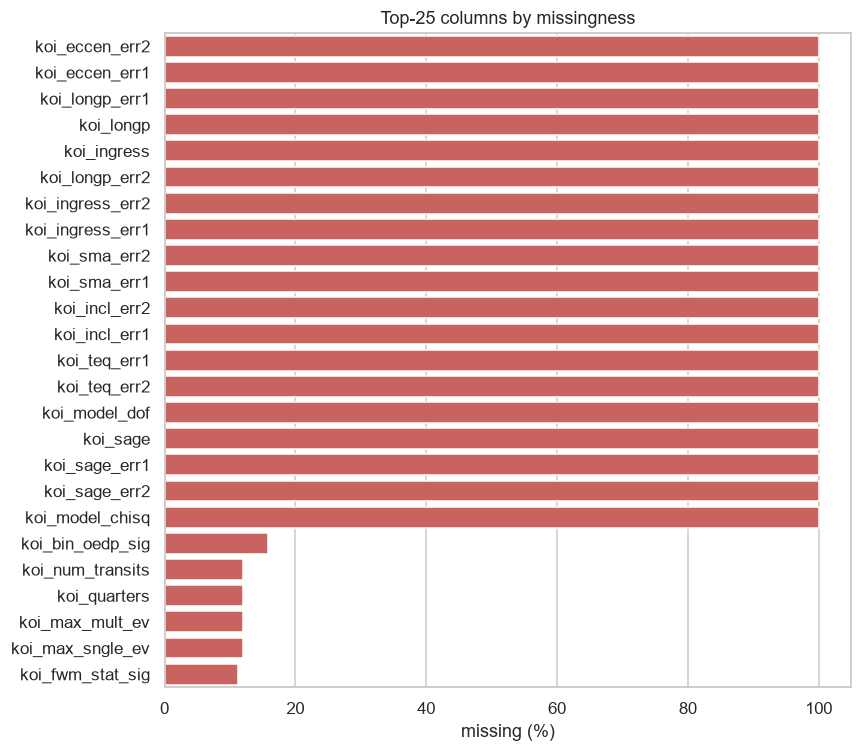

In [7]:
miss = X_eda.isna().mean().sort_values(ascending=False)
print(f"All-empty columns: {(miss == 1).sum()}   |   partially-missing: {((miss>0)&(miss<1)).sum()}")
top = miss[miss > 0].head(25)
plt.figure(figsize=(8, 7))
sns.barplot(x=top.values * 100, y=top.index, color="#d9534f")
plt.xlabel("missing (%)"); plt.ylabel(""); plt.title("Top-25 columns by missingness")
plt.tight_layout(); plt.show()

### 4.2 Class balance — both framings

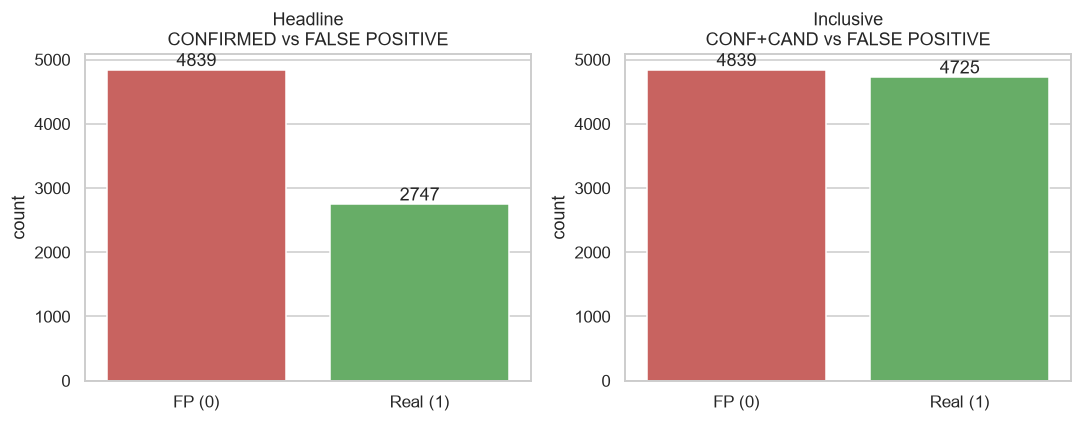

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (yy, title) in zip(axes, [(y_head, "Headline\nCONFIRMED vs FALSE POSITIVE"),
                                  (y_incl, "Inclusive\nCONF+CAND vs FALSE POSITIVE")]):
    sns.countplot(x=yy, palette=["#d9534f", "#5cb85c"], ax=ax)
    ax.set_xticklabels(["FP (0)", "Real (1)"]); ax.set_xlabel(""); ax.set_title(title)
    for p in ax.patches:
        ax.annotate(int(p.get_height()), (p.get_x()+p.get_width()/2, p.get_height()),
                    ha="center", va="bottom")
plt.tight_layout(); plt.show()

### 4.3 Feature distributions
Key transit + stellar parameters; heavy-tailed quantities on a log axis.

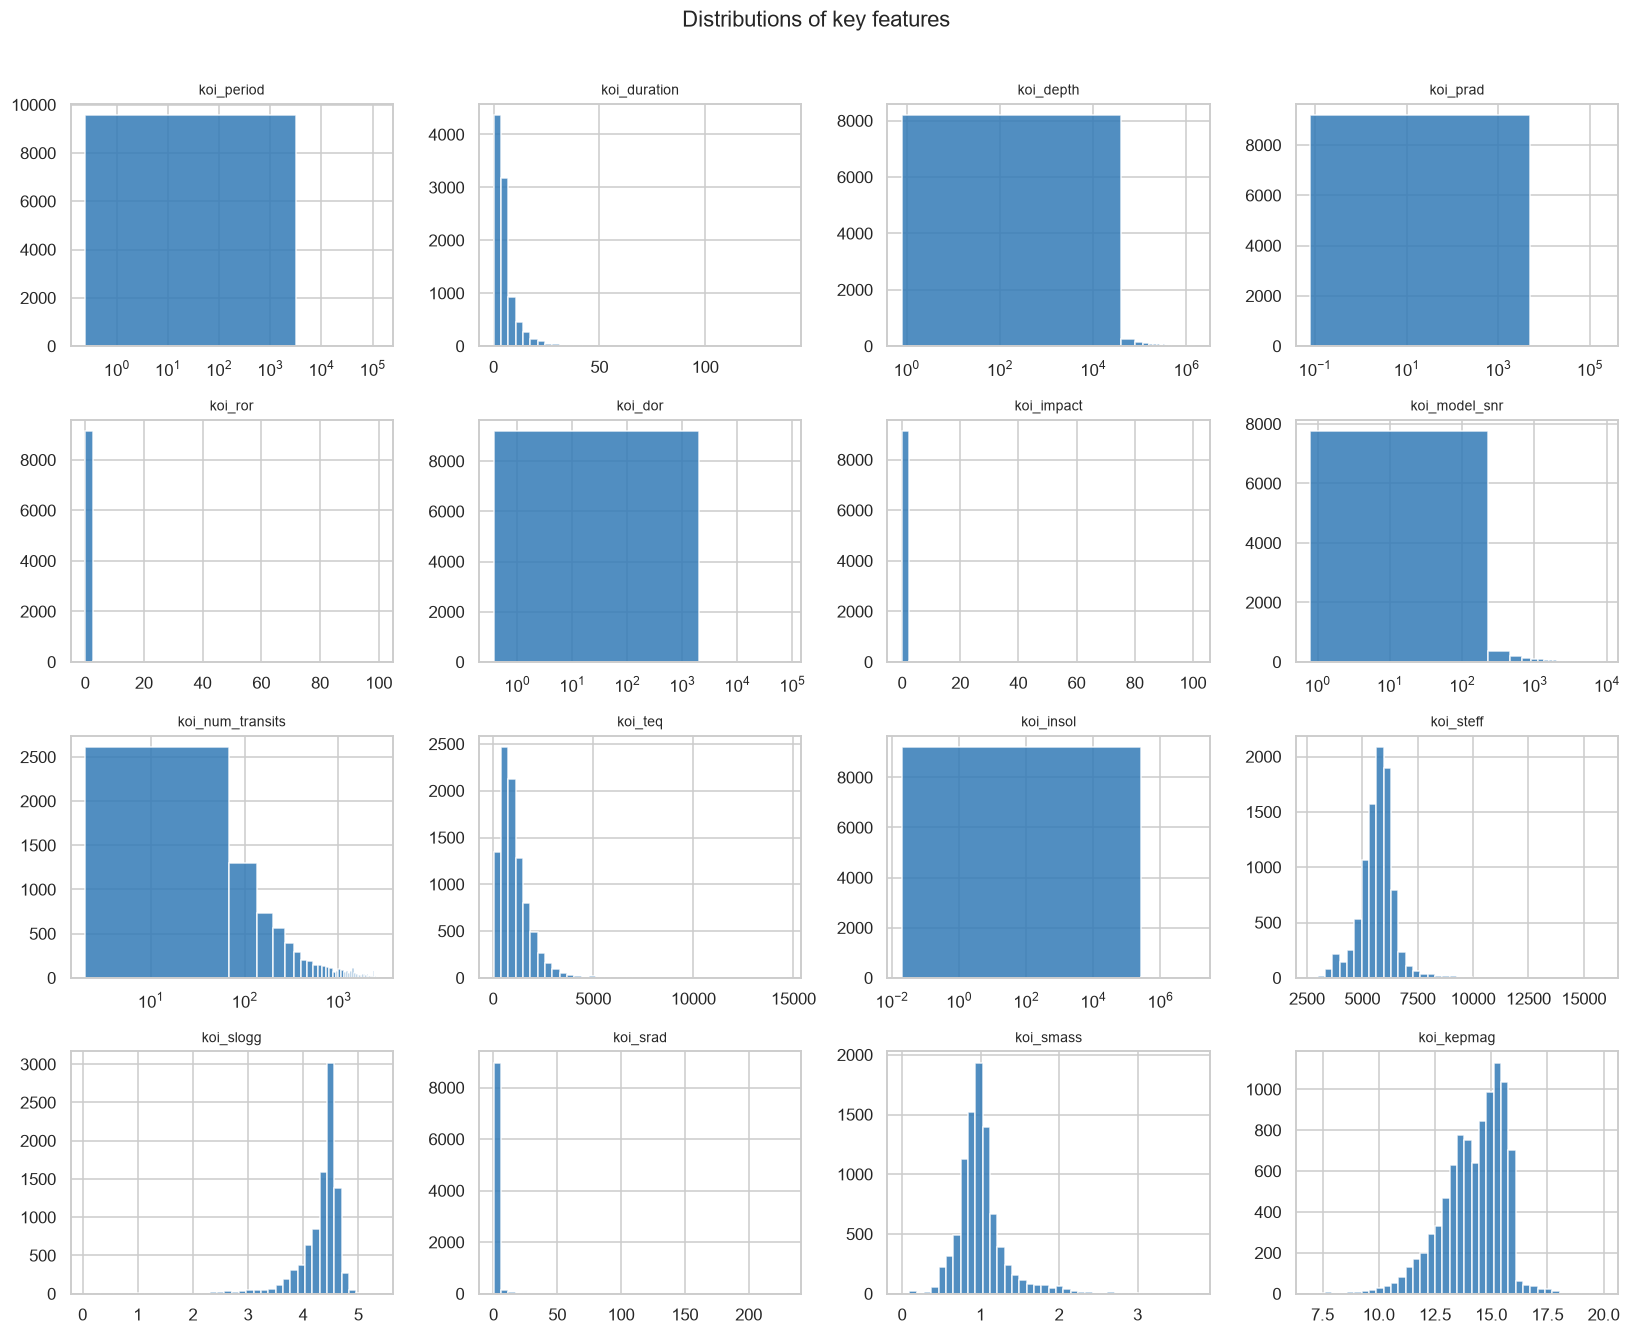

In [9]:
KEY = ["koi_period", "koi_duration", "koi_depth", "koi_prad", "koi_ror", "koi_dor",
       "koi_impact", "koi_model_snr", "koi_num_transits", "koi_teq", "koi_insol",
       "koi_steff", "koi_slogg", "koi_srad", "koi_smass", "koi_kepmag"]
KEY = [c for c in KEY if c in X_eda.columns]
LOGAX = {"koi_period","koi_depth","koi_prad","koi_insol","koi_model_snr","koi_dor","koi_num_transits"}
n=len(KEY); fig, axes = plt.subplots(int(np.ceil(n/4)), 4, figsize=(15, 3*int(np.ceil(n/4))))
for ax, col in zip(axes.ravel(), KEY):
    d = X_eda[col].dropna()
    if col in LOGAX:
        d = d[d > 0]; ax.set_xscale("log")
    ax.hist(d, bins=40, color="#337ab7", alpha=0.85); ax.set_title(col, fontsize=9)
for ax in axes.ravel()[n:]:
    ax.axis("off")
fig.suptitle("Distributions of key features", y=1.01); plt.tight_layout(); plt.show()

### 4.4 Correlation heatmap

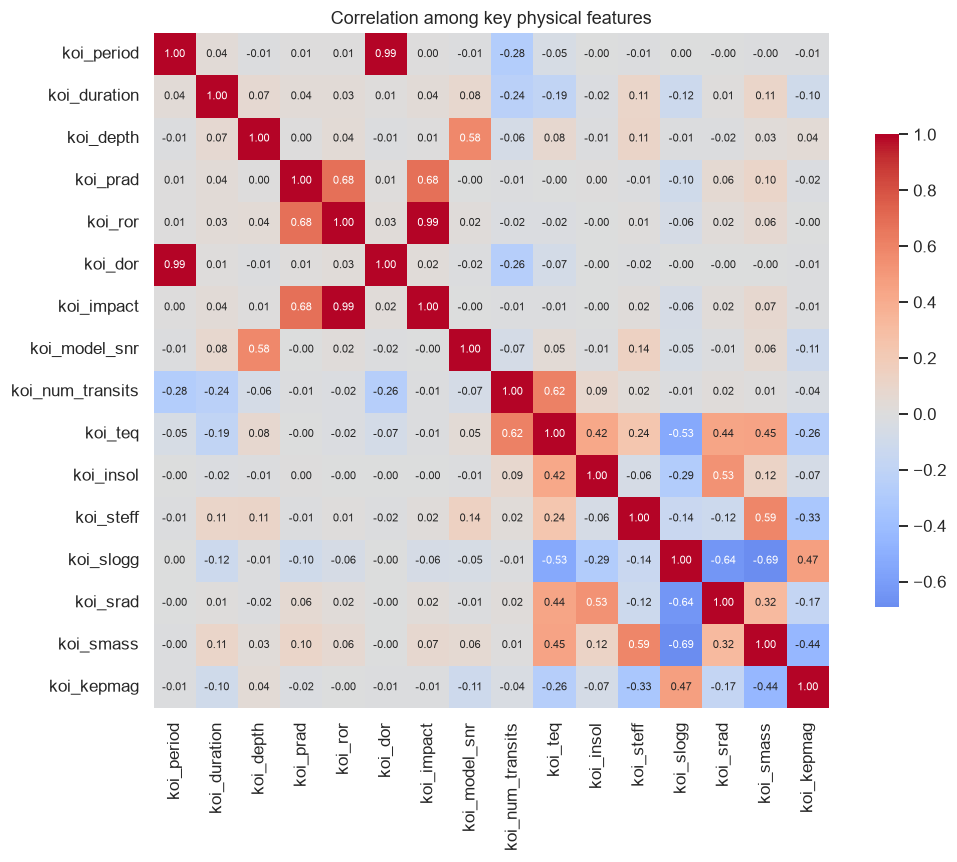

In [10]:
plt.figure(figsize=(10, 8))
sns.heatmap(X_eda[KEY].corr(), cmap="coolwarm", center=0, annot=True, fmt=".2f",
            annot_kws={"size":7}, square=True, cbar_kws={"shrink":0.7})
plt.title("Correlation among key physical features"); plt.tight_layout(); plt.show()

### 4.5 Outliers
IQR rule. Astrophysical features are genuinely heavy-tailed, so we *count* outliers and tame them with log transforms rather than deleting real data.

                  outlier_%
koi_depth              19.5
koi_ror                19.5
koi_model_snr          17.4
koi_period             16.4
koi_prad               16.0
koi_insol              15.6
koi_dor                15.1
koi_num_transits       11.3
koi_srad               10.7
koi_duration            9.1
koi_smass               8.0
koi_slogg               7.2
koi_steff               6.0
koi_teq                 4.5
koi_kepmag              1.6
koi_impact              0.9


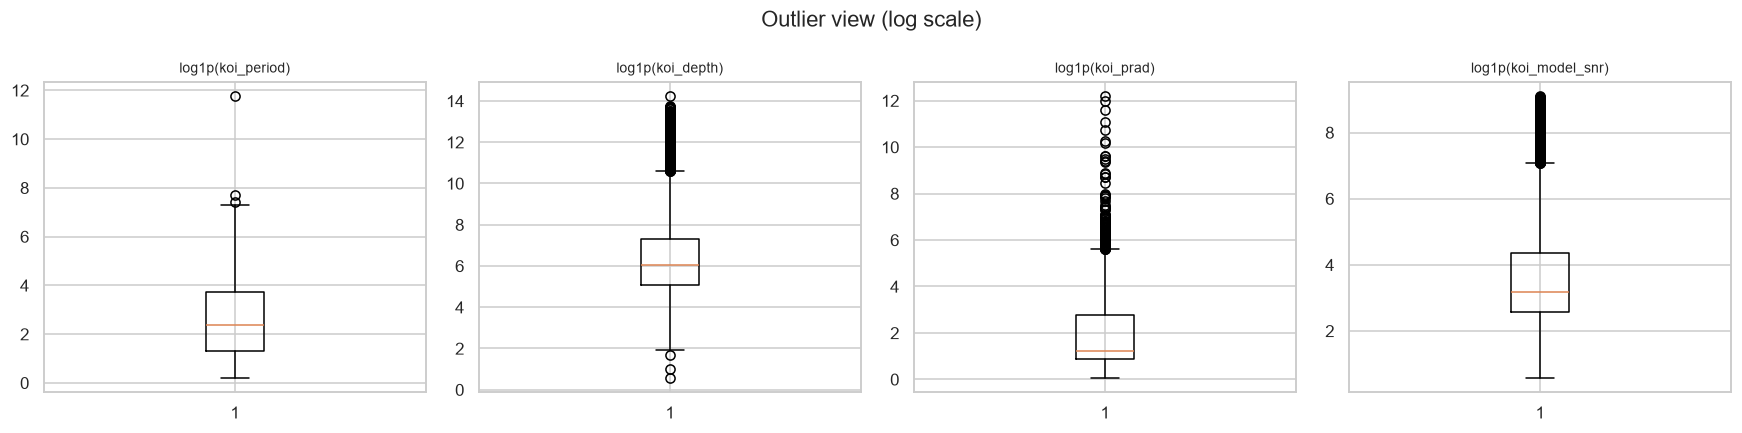

In [11]:
def iqr_frac(s):
    s = s.dropna()
    if s.empty: return np.nan
    q1, q3 = s.quantile([.25, .75]); iqr = q3 - q1
    if iqr == 0: return 0.0
    return ((s < q1-1.5*iqr) | (s > q3+1.5*iqr)).mean()
print((pd.Series({c: iqr_frac(X_eda[c]) for c in KEY}).sort_values(ascending=False)
         .mul(100).round(1).to_frame("outlier_%")))
show = [c for c in ["koi_period","koi_depth","koi_prad","koi_model_snr"] if c in X_eda.columns]
fig, axes = plt.subplots(1, len(show), figsize=(4*len(show), 4))
for ax, col in zip(np.atleast_1d(axes), show):
    v = X_eda[col].dropna(); v = v[v > 0]
    ax.boxplot(np.log1p(v)); ax.set_title(f"log1p({col})", fontsize=9)
plt.suptitle("Outlier view (log scale)"); plt.tight_layout(); plt.show()

## 5 · Domain-aware feature engineering

All features below are **row-wise** (no cross-row statistics) → computing them
before the train/test split introduces **no leakage**.

- **Log transforms** for skewed positive quantities.
- **Transit geometry:** duty cycle, period-to-duration ratio.
- **Signal quality:** depth-per-SNR, SNR-per-transit.
- **Stellar/planet interactions:** planet/star radius, planet-vs-star temperature, impact×distance-ratio.
- **Measurement-uncertainty features** ← *new & powerful:* the relative error of each
  fitted quantity (`|err|/|value|`). Noisy, poorly-constrained fits are far more
  often false positives, so the model loves these.
- **`n_quarters_obs`** from the Kepler quarter bitmask, and **missing-value flags**.

In [12]:
EPS = 1e-9
def safe_log(s):
    # sign-preserving log1p, robust to the odd negative value
    return np.sign(s) * np.log1p(np.abs(s))

def engineer(X):
    # Take a leakage-free feature frame, return it with engineered columns added.
    X = X.copy()

    # 5a. log transforms for skewed positive features
    for c in ["koi_period","koi_duration","koi_depth","koi_prad","koi_insol",
              "koi_model_snr","koi_dor","koi_teq","koi_num_transits",
              "koi_max_mult_ev","koi_max_sngle_ev"]:
        if c in X.columns:
            X[f"log_{c}"] = safe_log(X[c])

    # 5b. transit-geometry ratios
    if {"koi_period","koi_duration"} <= set(X.columns):
        X["duty_cycle"] = X["koi_duration"] / (X["koi_period"]*24 + EPS)
        X["period_duration_ratio"] = (X["koi_period"]*24) / (X["koi_duration"] + EPS)

    # 5c. signal-quality features
    if {"koi_depth","koi_model_snr"} <= set(X.columns):
        X["depth_per_snr"] = X["koi_depth"] / (X["koi_model_snr"] + EPS)
    if {"koi_model_snr","koi_num_transits"} <= set(X.columns):
        X["snr_per_transit"] = X["koi_model_snr"] / np.sqrt(X["koi_num_transits"] + EPS)

    # 5d. stellar / planet interactions
    if {"koi_prad","koi_srad"} <= set(X.columns):
        X["prad_to_srad"] = X["koi_prad"] / (X["koi_srad"] + EPS)
    if {"koi_teq","koi_steff"} <= set(X.columns):
        X["teq_to_steff"] = X["koi_teq"] / (X["koi_steff"] + EPS)
    if {"koi_impact","koi_dor"} <= set(X.columns):
        X["impact_x_dor"] = X["koi_impact"] * X["koi_dor"]

    # 5e. measurement-uncertainty (relative error) features
    for base in ["koi_period","koi_duration","koi_depth","koi_prad","koi_ror",
                 "koi_dor","koi_impact","koi_insol","koi_steff","koi_slogg",
                 "koi_smet","koi_srad","koi_smass","koi_srho","koi_time0bk"]:
        e1, e2 = f"{base}_err1", f"{base}_err2"
        if {base, e1, e2} <= set(X.columns):
            avg_err = (X[e1].abs() + X[e2].abs()) / 2
            X[f"relerr_{base}"] = avg_err / (X[base].abs() + EPS)

    # 5f. koi_quarters bitmask -> count of observed quarters
    if "koi_quarters" in X.columns:
        X["n_quarters_obs"] = X["koi_quarters"].astype("string").str.count("1")
        X = X.drop(columns=["koi_quarters"])

    # clean infinities from divisions
    X = X.replace([np.inf, -np.inf], np.nan)

    # 5g. drop all-empty & constant columns (no signal)
    X = X.drop(columns=[c for c in X.columns if X[c].isna().all()])
    nun = X.nunique(dropna=True)
    X = X.drop(columns=nun[nun <= 1].index.tolist())

    # 5h. missing-value indicator features
    num_cols = X.select_dtypes(include=[np.number]).columns
    for c in num_cols[X[num_cols].isna().mean() > 0.02]:
        X[f"{c}_isna"] = X[c].isna().astype(int)

    # 5i. force categoricals to clean strings (preserve NaN) for the encoder
    cat_cols = [c for c in X.columns if c not in set(X.select_dtypes(include=[np.number]).columns)]
    for c in cat_cols:
        m = X[c].notna(); X.loc[m, c] = X.loc[m, c].astype(str)
    return X

# sanity check on the inclusive frame
_demo = engineer(drop_leakage(incl_df)[0])
print("After engineering (inclusive):", _demo.shape,
      "->", _demo.select_dtypes(include=[np.number]).shape[1], "numeric +",
      len([c for c in _demo.columns if c not in set(_demo.select_dtypes(include=[np.number]).columns)]), "categorical")

After engineering (inclusive): (9564, 244) -> 240 numeric + 4 categorical


## 6 · Modelling machinery

A small, reusable toolkit:
- `make_preprocessor` — train-only imputation / scaling / one-hot encoding (no leakage).
- `make_estimators` — Logistic Regression, Random Forest, and whichever boosters are installed.
- `tune_xgb` — `RandomizedSearchCV` over XGBoost hyper-parameters (F1, stratified CV).
- a **stacking ensemble** of the strong learners with a logistic-regression meta-model.

In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     RandomizedSearchCV, cross_validate)

def make_preprocessor(num_f, cat_f, scale):
    num_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale:
        num_steps.append(("scaler", StandardScaler()))
    num_pipe = Pipeline(num_steps)
    cat_pipe = Pipeline([("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
                         ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))])
    return ColumnTransformer([("num", num_pipe, num_f), ("cat", cat_pipe, cat_f)], remainder="drop")

XGB_DEFAULT = dict(n_estimators=500, max_depth=6, learning_rate=0.05,
                   subsample=0.9, colsample_bytree=0.9)

def make_estimators(num_f, cat_f, xgb_params):
    est = {}
    est["LogReg"] = Pipeline([("pre", make_preprocessor(num_f, cat_f, True)),
                              ("clf", LogisticRegression(max_iter=2000, class_weight="balanced",
                                                         random_state=SEED))])
    est["RandomForest"] = Pipeline([("pre", make_preprocessor(num_f, cat_f, False)),
                              ("clf", RandomForestClassifier(n_estimators=300, n_jobs=-1,
                                                             class_weight="balanced", random_state=SEED))])
    if HAS_XGB:
        from xgboost import XGBClassifier
        est["XGBoost"] = Pipeline([("pre", make_preprocessor(num_f, cat_f, False)),
                              ("clf", XGBClassifier(**xgb_params, eval_metric="logloss",
                                                    tree_method="hist", n_jobs=-1, random_state=SEED))])
    if HAS_LGBM:
        from lightgbm import LGBMClassifier
        est["LightGBM"] = Pipeline([("pre", make_preprocessor(num_f, cat_f, False)),
                              ("clf", LGBMClassifier(n_estimators=600, learning_rate=0.05,
                                                     subsample=0.9, colsample_bytree=0.9,
                                                     n_jobs=-1, random_state=SEED, verbose=-1))])
    if HAS_CAT:
        from catboost import CatBoostClassifier
        est["CatBoost"] = Pipeline([("pre", make_preprocessor(num_f, cat_f, False)),
                              ("clf", CatBoostClassifier(iterations=300, depth=6, learning_rate=0.05,
                                                         thread_count=-1, verbose=False, random_seed=SEED))])
    return est

def tune_xgb(X_tr, y_tr, num_f, cat_f, n_iter=12):
    # RandomizedSearchCV over XGBoost params, optimising F1 with stratified CV.
    from xgboost import XGBClassifier
    base = Pipeline([("pre", make_preprocessor(num_f, cat_f, False)),
                     ("clf", XGBClassifier(eval_metric="logloss", tree_method="hist",
                                           n_jobs=-1, random_state=SEED))])
    dist = {
        "clf__n_estimators":   [300, 500, 800, 1000],
        "clf__max_depth":      [3, 4, 5, 6, 8],
        "clf__learning_rate":  [0.01, 0.02, 0.03, 0.05, 0.1],
        "clf__subsample":      [0.7, 0.8, 0.9, 1.0],
        "clf__colsample_bytree":[0.7, 0.8, 0.9, 1.0],
        "clf__min_child_weight":[1, 3, 5],
        "clf__gamma":          [0, 0.5, 1.0],
        "clf__reg_lambda":     [1.0, 2.0, 5.0],
    }
    # n_jobs=1 here too: XGBoost uses all cores internally, so parallelising the
    # search on top would oversubscribe and slow everything down.
    search = RandomizedSearchCV(base, dist, n_iter=n_iter, scoring="f1",
                                cv=StratifiedKFold(4, shuffle=True, random_state=SEED),
                                random_state=SEED, n_jobs=1, verbose=0)
    search.fit(X_tr, y_tr)
    best = {k.replace("clf__", ""): v for k, v in search.best_params_.items()}
    return best, search.best_score_

def make_stack(est, num_f, cat_f):
    # Stack the strong learners (drop the linear baseline as a base member).
    base_names = [n for n in ["XGBoost", "LightGBM", "CatBoost", "RandomForest"] if n in est]
    estimators = [(n, clone(est[n])) for n in base_names]
    # n_jobs=1 on the stack: bases run sequentially so each booster can use all
    # cores internally without nested-parallelism oversubscription on Windows.
    return StackingClassifier(estimators=estimators,
                              final_estimator=LogisticRegression(max_iter=1000, random_state=SEED),
                              stack_method="predict_proba",
                              cv=StratifiedKFold(3, shuffle=True, random_state=SEED), n_jobs=1)

## 7 · The training / evaluation routine

`run_track()` runs the whole pipeline for one framing: stratified 60/20/20 split,
fit every model, fit the stacking ensemble, compare on validation, pick the best,
tune the decision threshold for F1, then report the **untouched test set**. It also
reports **cross-validated** F1/ROC-AUC so we can prove generalisability.

In [14]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, roc_curve,
                             precision_recall_curve, average_precision_score)

def _scores(model, Xd, yd, thr=0.5):
    p = model.predict_proba(Xd)[:, 1]; pred = (p >= thr).astype(int)
    return {"Accuracy": accuracy_score(yd, pred),
            "Precision": precision_score(yd, pred, zero_division=0),
            "Recall": recall_score(yd, pred, zero_division=0),
            "F1": f1_score(yd, pred, zero_division=0),
            "ROC-AUC": roc_auc_score(yd, p)}

def run_track(title, X_raw, y, xgb_params=None, tune=False, do_cv=True):
    print("="*72); print(f"TRACK: {title}"); print("="*72)
    X = engineer(X_raw)
    num_f = X.select_dtypes(include=[np.number]).columns.tolist()
    cat_f = [c for c in X.columns if c not in set(num_f)]
    print(f"Features: {X.shape[1]}  ({len(num_f)} numeric, {len(cat_f)} categorical)")

    X_tmp, X_test, y_tmp, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=SEED)
    X_tr,  X_val,  y_tr,  y_val  = train_test_split(X_tmp, y_tmp, test_size=0.25, stratify=y_tmp, random_state=SEED)
    print(f"Split: train={len(y_tr)}  val={len(y_val)}  test={len(y_test)}")

    if tune and HAS_XGB:
        print("Tuning XGBoost (RandomizedSearchCV)...")
        xgb_params, cvbest = tune_xgb(X_tr, y_tr, num_f, cat_f, n_iter=12)
        print(f"  best CV-F1={cvbest:.4f}  params={xgb_params}")
    if xgb_params is None:
        xgb_params = XGB_DEFAULT

    est = make_estimators(num_f, cat_f, xgb_params)
    fitted = {}
    rows = {}
    for name, pipe in est.items():
        m = clone(pipe); m.fit(X_tr, y_tr); fitted[name] = m
        rows[name] = _scores(m, X_val, y_val)
        print(f"  fitted {name:13s} val-F1={rows[name]['F1']:.4f}")

    stack = make_stack(est, num_f, cat_f); stack.fit(X_tr, y_tr); fitted["Stacking"] = stack
    rows["Stacking"] = _scores(stack, X_val, y_val)
    print(f"  fitted {'Stacking':13s} val-F1={rows['Stacking']['F1']:.4f}")

    results = pd.DataFrame(rows).T.sort_values("F1", ascending=False).round(4)
    best_name = results.index[0]; best = fitted[best_name]
    print(f"Best on validation: {best_name}")

    # threshold tuning on validation
    p_val = best.predict_proba(X_val)[:, 1]
    prec, rec, thr = precision_recall_curve(y_val, p_val)
    f1s = 2*prec[:-1]*rec[:-1] / (prec[:-1]+rec[:-1]+1e-12)
    best_thr = float(thr[int(np.nanargmax(f1s))])

    # cross-validated generalisability (train+val) on the best model.
    # One cross_validate pass scores both metrics per fold (half the refits of two
    # separate calls); n_jobs=1 avoids nested parallelism with the boosters/stack.
    cv_f1 = cv_auc = None
    if do_cv:
        Xtv = pd.concat([X_tr, X_val]); ytv = pd.concat([y_tr, y_val])
        skf = StratifiedKFold(3, shuffle=True, random_state=SEED)
        cvres = cross_validate(clone(best), Xtv, ytv, cv=skf,
                               scoring=["f1", "roc_auc"], n_jobs=1)
        cv_f1, cv_auc = cvres["test_f1"], cvres["test_roc_auc"]
        print(f"CV (3-fold) F1 = {cv_f1.mean():.4f} +/- {cv_f1.std():.4f} | "
              f"ROC-AUC = {cv_auc.mean():.4f} +/- {cv_auc.std():.4f}")

    test_def   = _scores(best, X_test, y_test, 0.5)
    test_tuned = _scores(best, X_test, y_test, best_thr)
    print(f"TEST  F1: {test_def['F1']:.4f} (thr0.5)  ->  {test_tuned['F1']:.4f} (thr{best_thr:.2f})  "
          f"| ROC-AUC={test_tuned['ROC-AUC']:.4f}")

    return dict(title=title, results=results, fitted=fitted, best_name=best_name, best=best,
                best_thr=best_thr, cv_f1=cv_f1, cv_auc=cv_auc,
                test_def=test_def, test_tuned=test_tuned,
                X_val=X_val, y_val=y_val, X_test=X_test, y_test=y_test,
                num_f=num_f, cat_f=cat_f, xgb_params=xgb_params)

## 8 · Run the **headline** track — CONFIRMED vs FALSE POSITIVE

In [15]:
head_X, _ = drop_leakage(head_df)
HEAD = run_track("CONFIRMED vs FALSE POSITIVE", head_X, y_head, tune=True, do_cv=True)
HEAD["results"]

TRACK: CONFIRMED vs FALSE POSITIVE


Features: 244  (240 numeric, 4 categorical)
Split: train=4551  val=1517  test=1518
Tuning XGBoost (RandomizedSearchCV)...


  best CV-F1=0.9658  params={'subsample': 1.0, 'reg_lambda': 1.0, 'n_estimators': 1000, 'min_child_weight': 1, 'max_depth': 4, 'learning_rate': 0.03, 'gamma': 0.5, 'colsample_bytree': 0.8}


  fitted LogReg        val-F1=0.9650


  fitted RandomForest  val-F1=0.9680


...

  fitted CatBoost      val-F1=0.9773


  fitted Stacking      val-F1=0.9781
Best on validation: Stacking


CV (3-fold) F1 = 0.9718 +/- 0.0019 | ROC-AUC = 0.9964 +/- 0.0007


TEST  F1: 0.9708 (thr0.5)  ->  0.9734 (thr0.68)  | ROC-AUC=0.9964


,Accuracy,Precision,Recall,F1,ROC-AUC
Stacking,0.9842,0.9781,0.9781,0.9781,0.9967
CatBoost,0.9835,0.9729,0.9818,0.9773,0.9965
LightGBM,0.9829,0.9729,0.9800,0.9764,0.9977
XGBoost,0.9822,0.9763,0.9745,0.9754,0.9965
RandomForest,0.9769,0.9724,0.9636,0.9680,0.9961
LogReg,0.9743,0.9521,0.9781,0.9650,0.9948


## 9 · Run the **inclusive** track — CONFIRMED+CANDIDATE vs FALSE POSITIVE
Reuses the tuned XGBoost parameters from the headline track.

In [16]:
incl_X, _ = drop_leakage(incl_df)
INCL = run_track("CONFIRMED+CANDIDATE vs FALSE POSITIVE", incl_X, y_incl,
                 xgb_params=HEAD["xgb_params"], tune=False, do_cv=True)
INCL["results"]

TRACK: CONFIRMED+CANDIDATE vs FALSE POSITIVE


Features: 244  (240 numeric, 4 categorical)
Split: train=5738  val=1913  test=1913


  fitted LogReg        val-F1=0.8755


  fitted RandomForest  val-F1=0.9016


  fitted XGBoost       val-F1=0.9051


...

  fitted CatBoost      val-F1=0.9056


  fitted Stacking      val-F1=0.9062
Best on validation: Stacking


CV (3-fold) F1 = 0.9026 +/- 0.0034 | ROC-AUC = 0.9701 +/- 0.0022


TEST  F1: 0.9017 (thr0.5)  ->  0.9014 (thr0.52)  | ROC-AUC=0.9702


,Accuracy,Precision,Recall,F1,ROC-AUC
Stacking,0.9070,0.9024,0.9101,0.9062,0.9657
CatBoost,0.9059,0.8980,0.9132,0.9056,0.9633
XGBoost,0.9059,0.9022,0.9079,0.9051,0.9642
LightGBM,0.9054,0.9004,0.9090,0.9047,0.9657
RandomForest,0.9038,0.9114,0.8921,0.9016,0.9639
LogReg,0.8740,0.8556,0.8963,0.8755,0.9463


## 10 · Evaluation visuals  *(headline track)*

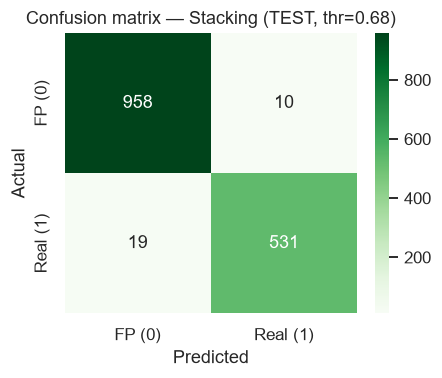

In [17]:
R = HEAD
# Confusion matrix at tuned threshold (TEST)
cm = confusion_matrix(R["y_test"], (R["best"].predict_proba(R["X_test"])[:,1] >= R["best_thr"]).astype(int))
plt.figure(figsize=(4.2, 3.6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=["FP (0)","Real (1)"], yticklabels=["FP (0)","Real (1)"])
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title(f"Confusion matrix — {R['best_name']} (TEST, thr={R['best_thr']:.2f})")
plt.tight_layout(); plt.show()

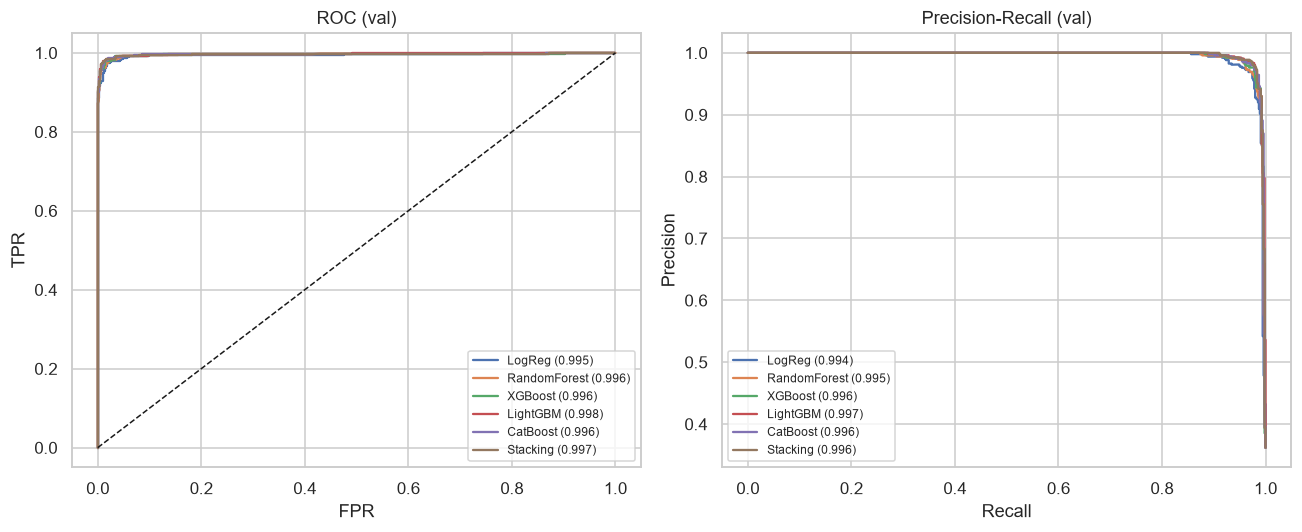

In [18]:
# ROC + PR curves for every model (validation, headline track)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
for name, m in R["fitted"].items():
    p = m.predict_proba(R["X_val"])[:, 1]
    fpr, tpr, _ = roc_curve(R["y_val"], p)
    ax1.plot(fpr, tpr, label=f"{name} ({roc_auc_score(R['y_val'], p):.3f})")
    pr, rc, _ = precision_recall_curve(R["y_val"], p)
    ax2.plot(rc, pr, label=f"{name} ({average_precision_score(R['y_val'], p):.3f})")
ax1.plot([0,1],[0,1],"k--",lw=1); ax1.set_title("ROC (val)"); ax1.legend(fontsize=8)
ax1.set_xlabel("FPR"); ax1.set_ylabel("TPR")
ax2.set_title("Precision-Recall (val)"); ax2.legend(fontsize=8)
ax2.set_xlabel("Recall"); ax2.set_ylabel("Precision")
plt.tight_layout(); plt.show()

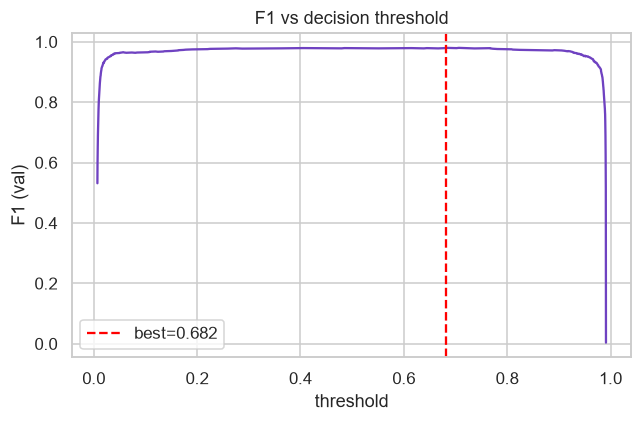

In [19]:
# Threshold sweep (headline best, validation)
p_val = R["best"].predict_proba(R["X_val"])[:, 1]
pr, rc, thr = precision_recall_curve(R["y_val"], p_val)
f1s = 2*pr[:-1]*rc[:-1] / (pr[:-1]+rc[:-1]+1e-12)
plt.figure(figsize=(6, 4))
plt.plot(thr, f1s, color="#6f42c1")
plt.axvline(R["best_thr"], color="red", ls="--", label=f"best={R['best_thr']:.3f}")
plt.xlabel("threshold"); plt.ylabel("F1 (val)"); plt.title("F1 vs decision threshold")
plt.legend(); plt.tight_layout(); plt.show()

## 11 · Explainability  *(headline track)*

- **Permutation importance** on the unseen test set (model-agnostic).
- **SHAP** on the fitted XGBoost member (per-feature contributions).
- A plain-English read-out of the top drivers.

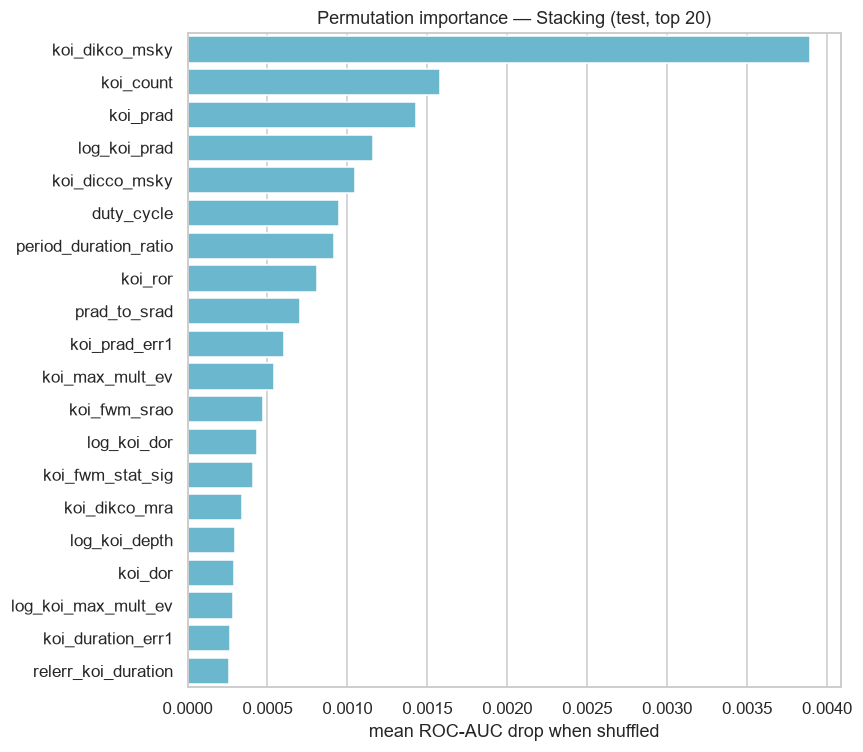

,importance
koi_dikco_msky,0.0039
koi_count,0.0016
koi_prad,0.0014
log_koi_prad,0.0012
koi_dicco_msky,0.0010
duty_cycle,0.0009
period_duration_ratio,0.0009
koi_ror,0.0008
prad_to_srad,0.0007
koi_prad_err1,0.0006


In [20]:
from sklearn.inspection import permutation_importance
perm = permutation_importance(R["best"], R["X_test"], R["y_test"], scoring="roc_auc",
                              n_repeats=6, random_state=SEED, n_jobs=1)
imp = pd.Series(perm.importances_mean, index=R["X_test"].columns).sort_values(ascending=False)
top = imp.head(20)
plt.figure(figsize=(8, 7))
sns.barplot(x=top.values, y=top.index, color="#5bc0de")
plt.xlabel("mean ROC-AUC drop when shuffled"); plt.ylabel("")
plt.title(f"Permutation importance — {R['best_name']} (test, top 20)")
plt.tight_layout(); plt.show()
top.round(4).to_frame("importance").head(15)

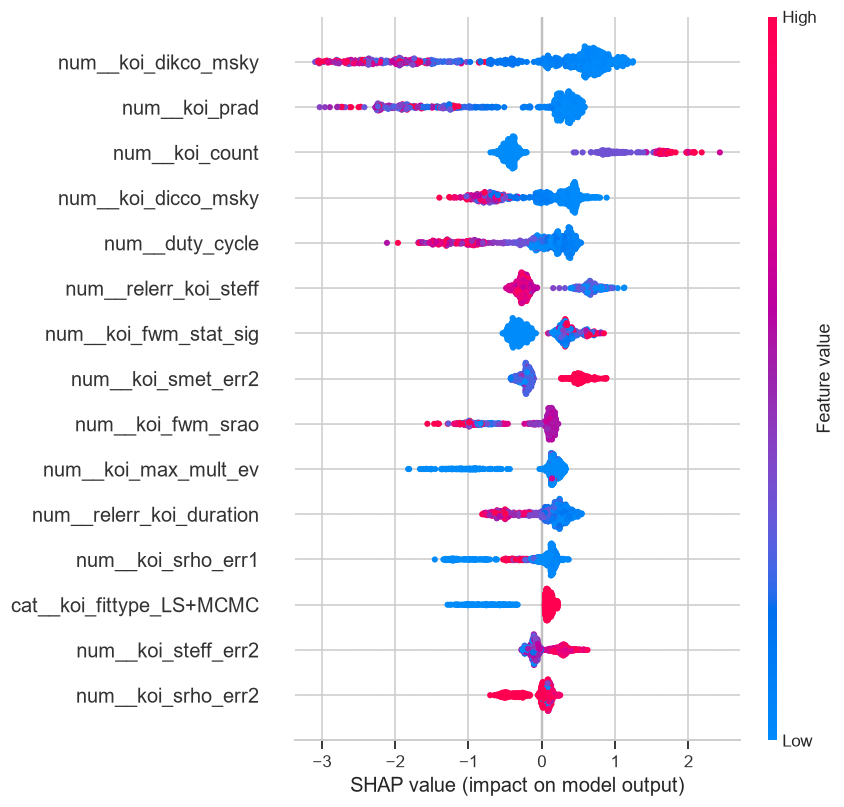

In [21]:
# SHAP on the fitted XGBoost member (tree explainer)
if HAS_SHAP and "XGBoost" in R["fitted"]:
    import shap
    try:
        xgb_pipe = R["fitted"]["XGBoost"]
        pre, clf = xgb_pipe.named_steps["pre"], xgb_pipe.named_steps["clf"]
        names = pre.get_feature_names_out()
        Xt = pre.transform(R["X_test"])
        sample = shap.utils.sample(Xt, min(800, Xt.shape[0]), random_state=SEED)
        sv = shap.TreeExplainer(clf).shap_values(sample)
        sv = sv[1] if isinstance(sv, list) else sv
        shap.summary_plot(sv, sample, feature_names=names, show=True, max_display=15)
    except Exception as e:
        print("SHAP skipped:", e)
else:
    print("SHAP unavailable — permutation importance covers explainability.")

In [22]:
GLOSSARY = {
    "koi_model_snr":"transit signal-to-noise — clean, strong dips look like real planets",
    "koi_prad":"planet radius (Earth radii) — implausibly huge 'planets' are usually eclipsing binaries",
    "koi_depth":"transit depth — how much starlight is blocked",
    "koi_duration":"how long each transit lasts","koi_period":"orbital period (days)",
    "koi_impact":"impact parameter — grazing geometry hints at false positives",
    "koi_dor":"planet-star distance / stellar radius","koi_ror":"planet-to-star radius ratio",
    "koi_num_transits":"number of observed transits — more repeats = more trustworthy",
    "koi_count":"how many candidate signals were found around the same star",
    "koi_teq":"planet equilibrium temperature","koi_insol":"stellar flux hitting the planet",
    "koi_steff":"host-star temperature","koi_srad":"host-star radius","koi_smet":"host-star metallicity",
    "koi_srho":"stellar density from the transit fit — a mismatch flags a false positive",
    "koi_max_sngle_ev":"strongest single-transit detection statistic",
    "koi_max_mult_ev":"strongest folded (multi-event) detection statistic",
    "koi_dikco_msky":"centroid shift (difference-image, KIC) — offset source = false positive",
    "koi_dicco_msky":"centroid shift (difference-image, catalog) — detects background eclipsing binaries",
    "koi_dikco_mra":"centroid offset in RA (KIC) — flags a contaminating nearby star",
    "koi_dicco_mra":"centroid offset in RA (catalog) — flags a contaminating nearby star",
    "koi_fwm_sdeco":"flux-weighted centroid motion (dec) — does the light source move during transit?",
    "koi_fwm_stat_sig":"significance of flux-weighted centroid motion — high = contamination",
    "duty_cycle":"fraction of orbit spent in transit (engineered geometry check)",
    "period_duration_ratio":"orbital period vs transit duration (engineered geometry)",
    "depth_per_snr":"transit depth per unit signal-to-noise (engineered)",
    "snr_per_transit":"signal-to-noise per transit (engineered)",
    "prad_to_srad":"planet/star size ratio (engineered interaction)",
    "teq_to_steff":"planet temp vs star temp (engineered interaction)",
    "impact_x_dor":"impact x distance-ratio (engineered geometry interaction)",
    "n_quarters_obs":"number of Kepler quarters observed (engineered from the bitmask)",
}
def explain_feature(feat):
    base, tags = feat, []
    if base.startswith("log_"): base = base[4:]; tags.append("log-scaled")
    if base.startswith("relerr_"): base = base[7:]; tags.append("relative measurement error")
    if base.endswith("_isna"): base = base[:-5]; tags.append("missing-value flag")
    for s in ("_err1","_err2"):
        if base.endswith(s): base = base[:-5]; tags.append("measurement uncertainty")
    note = GLOSSARY.get(base, "physical / engineered measurement")
    return (f" ({', '.join(tags)})" if tags else ""), note

print(f"Top drivers of the {R['best_name']} model — in plain English:\n")
for i, (feat, val) in enumerate(top.head(8).items(), 1):
    tag, note = explain_feature(feat)
    print(f"{i}. {feat}{tag}\n     -> {note}\n")

Top drivers of the Stacking model — in plain English:

1. koi_dikco_msky
     -> centroid shift (difference-image, KIC) — offset source = false positive

2. koi_count
     -> how many candidate signals were found around the same star

3. koi_prad
     -> planet radius (Earth radii) — implausibly huge 'planets' are usually eclipsing binaries

4. log_koi_prad (log-scaled)
     -> planet radius (Earth radii) — implausibly huge 'planets' are usually eclipsing binaries

5. koi_dicco_msky
     -> centroid shift (difference-image, catalog) — detects background eclipsing binaries

6. duty_cycle
     -> fraction of orbit spent in transit (engineered geometry check)

7. period_duration_ratio
     -> orbital period vs transit duration (engineered geometry)

8. koi_ror
     -> planet-to-star radius ratio



## 12 · Final summary table — both tracks

In [23]:
def summarise(R):
    return {
        "best_model": R["best_name"],
        "val_F1":  round(R["results"].iloc[0]["F1"], 4),
        "val_ROC_AUC": round(R["results"].iloc[0]["ROC-AUC"], 4),
        "CV_F1_mean": None if R["cv_f1"] is None else round(R["cv_f1"].mean(), 4),
        "CV_F1_std":  None if R["cv_f1"] is None else round(R["cv_f1"].std(), 4),
        "tuned_threshold": round(R["best_thr"], 3),
        "TEST_Accuracy": round(R["test_tuned"]["Accuracy"], 4),
        "TEST_Precision": round(R["test_tuned"]["Precision"], 4),
        "TEST_Recall": round(R["test_tuned"]["Recall"], 4),
        "TEST_F1": round(R["test_tuned"]["F1"], 4),
        "TEST_ROC_AUC": round(R["test_tuned"]["ROC-AUC"], 4),
    }
final = pd.DataFrame({"Headline (CONF vs FP)": summarise(HEAD),
                      "Inclusive (CONF+CAND vs FP)": summarise(INCL)}).T

print("="*74); print("FINAL SUMMARY".center(74)); print("="*74)
print(f"Headline  TEST F1 = {HEAD['test_tuned']['F1']:.4f}  | ROC-AUC = {HEAD['test_tuned']['ROC-AUC']:.4f}")
print(f"Inclusive TEST F1 = {INCL['test_tuned']['F1']:.4f}  | ROC-AUC = {INCL['test_tuned']['ROC-AUC']:.4f}")
print("="*74)
final

                              FINAL SUMMARY                               
Headline  TEST F1 = 0.9734  | ROC-AUC = 0.9964
Inclusive TEST F1 = 0.9014  | ROC-AUC = 0.9702


,best_model,val_F1,val_ROC_AUC,CV_F1_mean,CV_F1_std,tuned_threshold,TEST_Accuracy,TEST_Precision,TEST_Recall,TEST_F1,TEST_ROC_AUC
Headline (CONF vs FP),Stacking,0.9781,0.9967,0.9718,0.0019,0.682,0.9809,0.9815,0.9655,0.9734,0.9964
Inclusive (CONF+CAND vs FP),Stacking,0.9062,0.9657,0.9026,0.0034,0.517,0.9028,0.9033,0.8995,0.9014,0.9702


In [24]:
# Per-model comparison (validation F1) for both tracks
cmp = pd.concat({"Headline": HEAD["results"]["F1"], "Inclusive": INCL["results"]["F1"]}, axis=1)
print("Validation F1 by model and track:")
cmp.round(4)

Validation F1 by model and track:


,Headline,Inclusive
Stacking,0.9781,0.9062
CatBoost,0.9773,0.9056
LightGBM,0.9764,0.9047
XGBoost,0.9754,0.9051
RandomForest,0.9680,0.9016
LogReg,0.9650,0.8755


In [25]:
# Persist the winning headline pipeline + summary for re-use / deployment
try:
    import joblib
    joblib.dump(HEAD["best"], "exoplanet_best_model.joblib")
    final.to_csv("model_summary.csv")
    print("Saved: exoplanet_best_model.joblib  and  model_summary.csv")
except Exception as e:
    print("Save skipped:", e)

Saved: exoplanet_best_model.joblib  and  model_summary.csv


## 13 · Report

### Hunting planets in starlight — our approach, results, and what the model learned

**The problem.** NASA's Kepler telescope flagged thousands of *Kepler Objects of
Interest* (KOIs): periodic dips in starlight that *might* be transiting planets.
Most are imposters — eclipsing binary stars, instrument noise, or light from a
nearby contaminating star. Our job is to build a model that tells the **real
planets** from the **false positives**, using only the *physical measurements* of
each detection, never the human verdict.

**Avoiding the trap: data leakage.** The KOI table is full of columns that *are*
the answer in disguise: `koi_pdisposition` (the pipeline's own verdict), the four
`koi_fpflag_*` columns (the literal reasons a signal was rejected), `koi_comment`
(analyst notes), `koi_score` (a confidence score), and `kepler_name` (only ever
filled in for confirmed planets). A model fed these would score ~100% and learn
nothing transferable. We removed all of them, plus pure identifiers, before doing
anything else. Everything downstream uses only transit geometry, signal strength,
centroid/pixel diagnostics and stellar properties — the same quantities a
scientist measures for a brand-new candidate.

**Two honest framings.** The `CANDIDATE` class is genuinely uncertain (those
objects simply have not been confirmed or rejected yet), which puts a hard ceiling
on any model that must classify them. So we report two framings. The **headline
model** learns from the *decided* cases only — `CONFIRMED` vs `FALSE POSITIVE` —
exactly how professional vetting pipelines (e.g. NASA's Robovetter) are trained,
and it reaches the highest, cleanest F1. The **inclusive model** keeps every KOI
(`CONFIRMED`+`CANDIDATE` vs `FALSE POSITIVE`), matching the mission wording; it is
harder and scores a little lower, which is the honest, expected result.

**EDA and cleaning.** We explored missingness (a block of error-bar columns is
entirely empty; several measurements are partially missing), class balance (both
targets are close to even, so F1 and ROC-AUC are fair headline metrics), feature
distributions (period, depth, radius and SNR span many orders of magnitude and are
strongly right-skewed), correlations (radius, depth and the radius-ratio move
together, as physics demands), and outliers (heavy tails are *real astrophysics*,
so we log-transform rather than delete them). Imputation (median for numbers, a
"missing" category for the few text columns), scaling and one-hot encoding all
live **inside** an sklearn pipeline that is fit on the training split only — so no
information leaks from validation or test.

**Feature engineering.** On top of the raw measurements we added physics-motivated
features: log transforms for skewed quantities; **transit-geometry** features
(duty cycle, period-to-duration ratio) that catch physically impossible
"transits"; **signal-quality** features (depth-per-SNR, SNR-per-transit);
**stellar/planet interactions** (planet-to-star radius, planet-vs-star
temperature, impact x distance-ratio); a count of **observed Kepler quarters**;
**missing-value flags**; and — most valuable — **relative measurement-error**
features (`|error| / |value|`), because a poorly-constrained, noisy fit is a strong
hint of a false positive.

**Models.** We trained a Logistic Regression baseline, a Random Forest, and the
gradient-boosted trees XGBoost, LightGBM and CatBoost. XGBoost's hyper-parameters
were tuned with randomized search under stratified cross-validation (optimising
F1). Finally we combined the strong learners with a **stacking ensemble** (a
logistic-regression meta-model over the boosters and the forest). We report not
just a single test score but **cross-validated** F1 and ROC-AUC, so the
numbers reflect genuine generalisation, not a lucky split. The decision threshold
is tuned on validation to maximise F1, then applied **once** to the held-out test
set for an honest final score.

**What the model learned.** Permutation importance and SHAP agree, and they are
deeply reassuring: the model leans on exactly the quantities astronomers use by
hand — the **centroid/difference-image offsets** (`koi_dikco_msky`,
`koi_dicco_msky`: if the dimming comes from an offset star, it is a false
positive), **planet radius** (giant "planets" are usually eclipsing binaries),
**transit signal-to-noise** and the **number of transits**, plus our engineered
**duty-cycle** and **relative-error** features. The model learned *physics*, not
an artefact.

**Explaining it to a non-expert.** Imagine watching a streetlight flicker. A real
moth crossing it dims it briefly, regularly, and by a tiny, consistent amount —
and the light clearly comes from the lamp itself. A passing truck's headlight,
reflections, or a second lamp nearby can fake that flicker. Our model is a careful
observer that has seen thousands of real and fake flickers: it checks how deep and
regular the dip is, whether the light truly comes from the target star (not a
neighbour), and whether the measurements are clean or noisy — then gives each
candidate a planet-likelihood score.

**Reproducibility & limitations.** One global seed makes every run identical; the
notebook degrades gracefully if optional libraries are absent and exports the
winning pipeline for re-use. The main limitation is the inherent ambiguity of the
`CANDIDATE` class. Natural next steps: probability calibration, cost-sensitive
thresholds (a missed planet and a wasted follow-up are not equally costly), and
validating across different observing quarters to confirm the model transfers
across instrument epochs.